# Chapter Summary

Dimensionality reduction is a machine learning technique used to reduce the number of features while preserving as much important information as possible.

As datasets become larger and more complex, high-dimensional data can increase computational costs, create visualization challenges, and negatively impact model performance.

This chapter introduces several popular dimensionality reduction techniques including Principal Component Analysis (PCA), Linear Discriminant Analysis (LDA), and t-Distributed Stochastic Neighbor Embedding (t-SNE). These methods help simplify datasets while maintaining meaningful information.

# Learning Objectives

After completing this chapter, students should be able to:

- Understand dimensionality reduction concepts.
- Explain the curse of dimensionality.
- Apply Principal Component Analysis (PCA).
- Apply Linear Discriminant Analysis (LDA).
- Visualize high-dimensional data using t-SNE.
- Compare PCA and LDA.
- Evaluate the impact of dimensionality reduction on machine learning performance.

## Introduction to Dimensionality Reduction

Modern datasets often contain hundreds or thousands of features.

While additional features may provide useful information, excessive dimensions can introduce several challenges:

- Increased computational cost.
- Higher memory consumption.
- Greater risk of overfitting.
- Difficult visualization.

This phenomenon is commonly known as the Curse of Dimensionality.

Dimensionality reduction techniques address these issues by transforming data into a lower-dimensional representation while preserving important information.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is one of the most widely used dimensionality reduction techniques.

PCA transforms the original features into a new set of orthogonal variables called principal components.

The principal components are ordered based on the amount of variance they explain.

Advantages of PCA:

- Reduces dimensionality.
- Removes redundancy.
- Improves visualization.
- Can improve model efficiency.

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (150, 4)
Reduced Shape: (150, 2)


In [4]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.92461872 0.05306648]


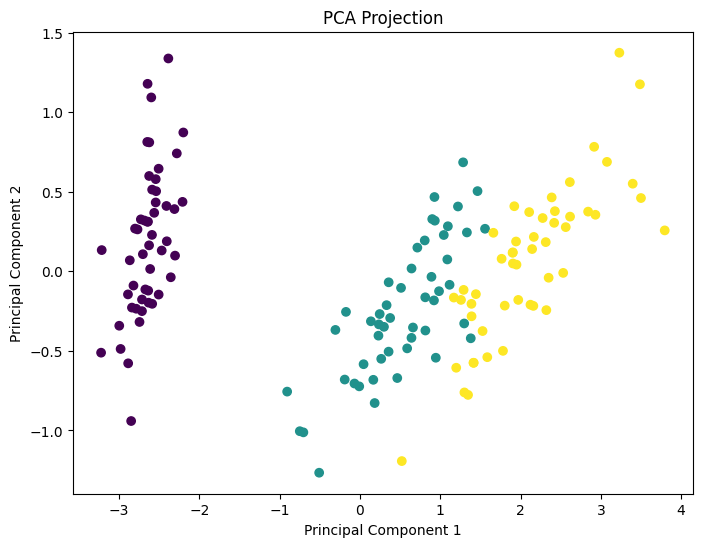

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.show()

PCA successfully reduced the original four-dimensional Iris dataset into two dimensions.

The transformed features retain most of the original information while making visualization easier.

## Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is both a dimensionality reduction technique and a classification method.

Unlike PCA, which focuses on maximizing variance, LDA focuses on maximizing class separability.

LDA is particularly useful when labeled data is available.

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(X, y)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_lda.shape)

Original Shape: (150, 4)
Reduced Shape: (150, 2)


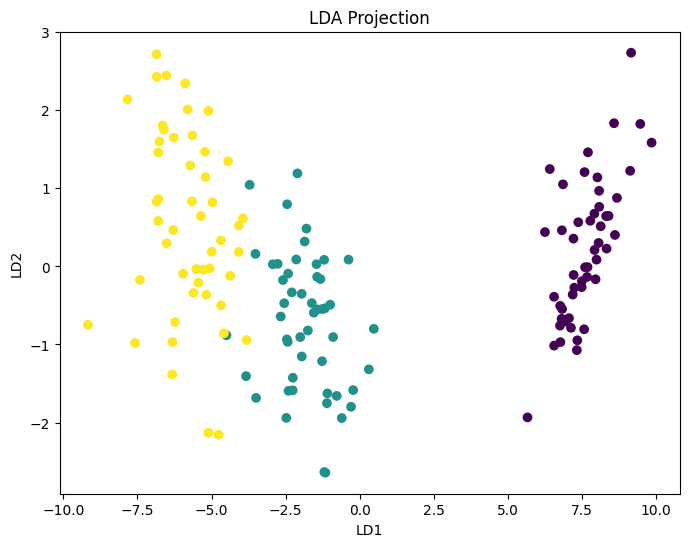

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y
)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection")

plt.show()

LDA attempts to maximize separation between classes.

Because the Iris dataset contains class labels, LDA can often produce better class separation than PCA.

## PCA vs LDA

Although PCA and LDA are both dimensionality reduction techniques, their objectives are different.

PCA:
- Unsupervised.
- Maximizes variance.
- Does not use target labels.

LDA:
- Supervised.
- Maximizes class separation.
- Uses target labels.

The choice between PCA and LDA depends on the machine learning task and available data.

## PCA vs LDA

Although PCA and LDA are both dimensionality reduction techniques, their objectives are different.

PCA:
- Unsupervised.
- Maximizes variance.
- Does not use target labels.

LDA:
- Supervised.
- Maximizes class separation.
- Uses target labels.

The choice between PCA and LDA depends on the machine learning task and available data.

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_tsne.shape)

Original Shape: (150, 4)
Reduced Shape: (150, 2)


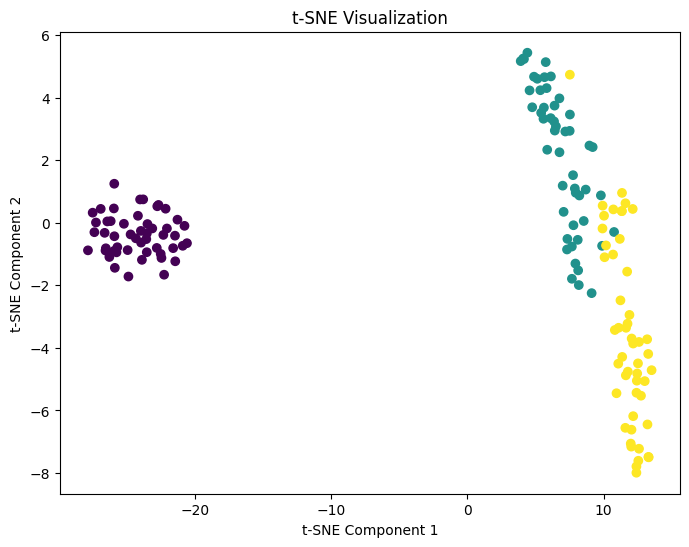

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization")

plt.show()

t-SNE creates a two-dimensional representation of the dataset while preserving neighborhood relationships between observations.

Unlike PCA, the axes produced by t-SNE do not have direct interpretability but are useful for visual exploration.

## Guidelines for Selecting Dimensionality Reduction Techniques

Different dimensionality reduction techniques serve different purposes.

General recommendations:

### Use PCA when:

- Reducing dimensionality before model training.
- Improving computational efficiency.
- Removing correlated features.

### Use LDA when:

- Labels are available.
- Class separation is important.
- Classification performance is a priority.

### Use t-SNE when:

- Visualizing complex datasets.
- Exploring cluster structures.
- Performing exploratory data analysis.

## Impact on Model Performance

Dimensionality reduction can influence machine learning performance in several ways.

Potential benefits:

- Faster training.
- Lower memory consumption.
- Reduced overfitting.
- Improved visualization.

Potential drawbacks:

- Information loss.
- Reduced interpretability.
- Lower accuracy if important features are removed.

Therefore, dimensionality reduction should be evaluated carefully before deployment.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


This experiment evaluates how PCA-reduced features perform when used as input for a Logistic Regression model.

The resulting accuracy demonstrates whether dimensionality reduction preserves sufficient information for classification.

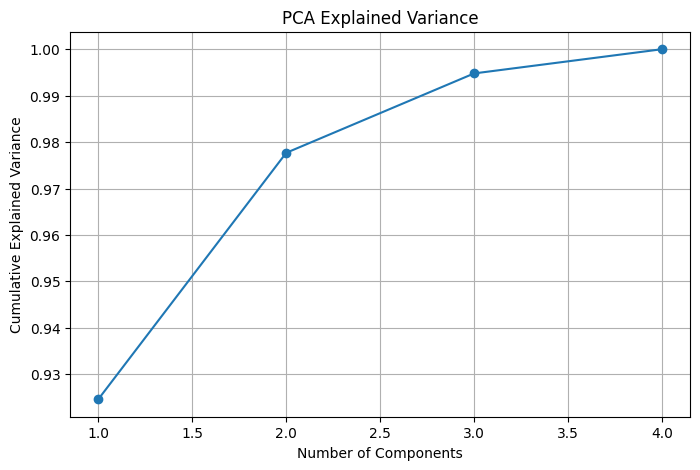

In [14]:
from sklearn.decomposition import PCA

pca_full = PCA()

pca_full.fit(X)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_.cumsum(),
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [15]:
print("PCA Shape:", X_pca.shape)
print("LDA Shape:", X_lda.shape)

PCA Shape: (150, 2)
LDA Shape: (150, 2)


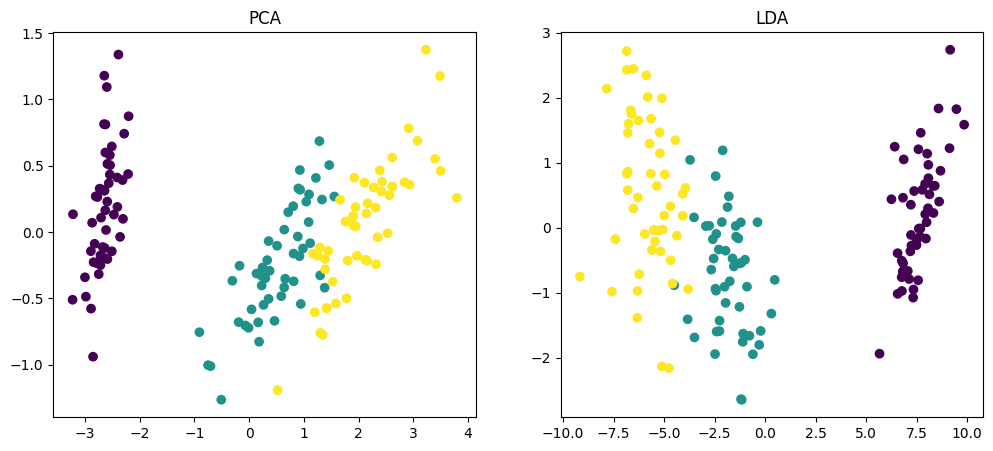

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

axes[0].set_title("PCA")

axes[1].scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y
)

axes[1].set_title("LDA")

plt.show()

# Discussion

This chapter explored several dimensionality reduction techniques available in scikit-learn.

Principal Component Analysis (PCA) was used to reduce feature dimensions while preserving variance. Linear Discriminant Analysis (LDA) was applied to maximize class separation using target labels. Additionally, t-SNE was introduced as a powerful visualization technique for exploring high-dimensional datasets.

The experiments demonstrated that dimensionality reduction can simplify datasets and improve computational efficiency while maintaining important information. However, selecting the appropriate technique depends on the specific machine learning task and data characteristics.

# Conclusion

Dimensionality reduction is an important technique for managing high-dimensional datasets.

In this chapter, PCA, LDA, and t-SNE were introduced and applied to the Iris dataset. Each technique serves different objectives, ranging from variance preservation to class separation and data visualization.

Understanding these methods helps machine learning practitioners improve efficiency, reduce complexity, and gain deeper insights into their data before model development.